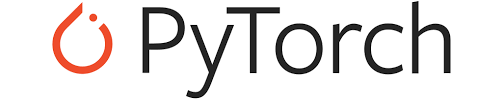

# **Introduction to PyTorch**

## **What is PyTorch?**

PyTorch is an open-source machine learning library developed by Meta AI.

It is widely used for:

- Deep Learning
- Neural Networks
- Computer Vision
- Natural Language Processing
- Scientific Computing

**Core Features:**
- Tensor-based computation (similar to NumPy):
  - A tensor is the basic data structure in PyTorch.
  - Like NumPy arrays, tensors can represent scalars (0D), vectors (1D), matrices (2D), or higher-dimensional data (3D+).
  - Most NumPy operations (addition, multiplication, broadcasting) work the same way on PyTorch tensors.
- Automatic differentiation (Autograd)
   - Autograd automatically computes derivatives of tensors
   - This is essential for training neural networks with gradient-based optimization.
- GPU acceleration (CUDA support)
    - PyTorch can perform computations on a GPU for speedup.
- Dynamic computation graphs
  - PyTorch uses dynamic (define-by-run) computation graphs.
  - The graph is created on the fly as operations occur, unlike static frameworks where you must define the full graph beforehand.
  - Makes debugging intuitive and flexible for models with variable input sizes or loops.

**Key Idea**

>PyTorch = NumPy + GPU + Deep Learning tools

## **PyTorch vs NumPy**

**Similarities**

| Feature              | NumPy | PyTorch |
| -------------------- | ----- | ------- |
| N-dimensional arrays | ✅     | ✅       |
| Broadcasting         | ✅     | ✅       |
| Vectorized ops       | ✅     | ✅       |


<br>

**Key Differences**

| Feature                | NumPy | PyTorch |
| ---------------------- | ----- | ------- |
| GPU support            | ❌     | ✅       |
| Automatic gradients    | ❌     | ✅       |
| Deep learning support  | ❌     | ✅       |
| Neural network modules | ❌     | ✅       |


## **What is a Tensor?**

A tensor is a multi-dimensional array that stores elements of a single data type.

**A tensor is simply a generalization of arrays.**

<br>

| Object | Tensor Type | Shape Example       |                   |
| ------ | ----------- | ------------------- |------------------ |
| Scalar | 0D          | `()`                |`5`                |
| Vector | 1D          | `(n,)`              |`[1, 2, 3]`        |
| Matrix | 2D          | `(m, n)`            |`[[1,2],[3,4]]`    |
| Tensor | ND          | `(d1, d2, ..., dn)` |Image, video, etc. |


<br>

👉 **Key idea:**

>A tensor = multi-dimensional array

**Real-world examples:**
- Dataset → 2D tensor (rows = samples, columns = features)
- Image → 3D tensor (height, width, channels)
- Batch of images → 4D tensor (batch, height, width, channels)

## **Convert NumPy → Tensor**

In [1]:
import numpy as np
import torch

arr = np.array([1, 2, 3])
t1 = torch.from_numpy(arr)
t2 = torch.as_tensor(arr)
t3 = torch.tensor(arr)

print(t1)
print(type(t1))

print(t2)
print(type(t2))

print(t3)
print(type(t3))

tensor([1, 2, 3])
<class 'torch.Tensor'>
tensor([1, 2, 3])
<class 'torch.Tensor'>
tensor([1, 2, 3])
<class 'torch.Tensor'>


**⚠️ Important Concept: Shared Memory**

| Method       | Memory Sharing |
| ------------ | -------------- |
| `from_numpy` | Yes            |
| `as_tensor`  | Usually yes    |
| `tensor`     | No (copy)      |


In [2]:
arr[0] = 99
print(t1)
print(t2)
print(t3)

tensor([99,  2,  3])
tensor([99,  2,  3])
tensor([1, 2, 3])


**Edge Cases & Pitfalls**
- Modifying NumPy affects tensor (unexpected bugs)
- GPU tensors cannot be created directly via from_numpy
- dtype mismatch may occur:

In [3]:
arr = np.array([1,2,3], dtype=np.int32)
torch.from_numpy(arr).dtype   # torch.int32

torch.int32

**Best Practice**

In [4]:
torch.tensor(arr)  # safer (copy)

tensor([1, 2, 3], dtype=torch.int32)

unless memory efficiency is critical.

<br>

## **Creating Tensors from Scratch**

In [5]:
import torch

# Scalar
a = torch.tensor(5)

# Vector
b = torch.tensor([1, 2, 3])

# Matrix
c = torch.tensor([[1, 2], [3, 4]])

# 3D tensor
d = torch.rand((2, 3, 4))

### **Key Properties**

In [6]:
print(c.shape)       # dimensions
print(c.dtype)       # data type
print(c.ndim)        # number of dimensions

torch.Size([2, 2])
torch.int64
2


**Common Confusions**
- A tensor is not only 3D+ → vectors and matrices are tensors.
- All elements must have same dtype.
- Shape ≠ size (numel() gives total elements).

**Changing Type**

In [7]:
x = torch.tensor([1,2,3])
x.dtype

torch.int64

In [8]:
xf1 = x.type(torch.float32)
xf1

tensor([1., 2., 3.])

In [9]:
xf1.dtype

torch.float32

or

In [10]:
xf2 = x.float()
xf2

tensor([1., 2., 3.])

In [11]:
xf2.dtype

torch.float32

**Pitfalls**
- Mixing types → implicit casting or errors


### **Basic Initializers**

In [12]:
torch.zeros((2,3))

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [13]:
torch.ones((2,3))

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [14]:
torch.empty((2,3))

tensor([[1.9255e+01, 0.0000e+00, 1.9232e+01],
        [0.0000e+00, 1.1210e-43, 0.0000e+00]])

**Important Notes**
- empty() does not initialize values
- May contain garbage memory

### **Range-Based**

In [15]:
torch.arange(0, 10, 2)

tensor([0, 2, 4, 6, 8])

In [16]:
torch.linspace(0, 1, steps=5)

tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

**Best when:**

<br>

| Use Case | Recommended Function | Why? |
| :--- | :--- | :--- |
| **Integer sequences** | `torch.arange(start, end, step)` | Works perfectly with whole numbers; `end` is exclusive. |
| **Floating point precision** | `torch.linspace(start, end, steps)` | Avoids "drift" by calculating values based on total count. |
| **Fixed step size** | `torch.arange` | Best when the interval (e.g., "every 0.5") is most important. |
| **Fixed number of points** | `torch.linspace` | Best when the final count (e.g., "exactly 100 values") is most important. |



### **Random Tensors**

**Distribution Differences**

| Function | Distribution           |
| -------- | ---------------------- |
| rand     | Uniform                |
| randn    | Normal (mean=0, std=1) |



In [17]:
torch.rand((2,3))     # uniform [0,1)

tensor([[0.5097, 0.8265, 0.8684],
        [0.0846, 0.9677, 0.0477]])

In [18]:
torch.randn((2,3))    # normal distribution

tensor([[ 1.1873,  1.2299,  0.4562],
        [ 0.4348,  0.5527, -0.2309]])

In [19]:
torch.randint(0,10,(2,3))  # never includes 10

tensor([[7, 3, 9],
        [1, 3, 5]])

- `randint(high)` is exclusive

### **Random Seed (Reproducibility)**

In PyTorch, torch.manual_seed(42) sets the initial state of the random number generator (RNG). Subsequent calls to a random function like torch.rand() produce a sequence of numbers, where each call advances the RNG state to a new value.

In [20]:
torch.manual_seed(42)
torch.rand((2,2))

tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])

In [21]:
torch.rand((2,2))

tensor([[0.3904, 0.6009],
        [0.2566, 0.7936]])

In [22]:
torch.manual_seed(42)
torch.rand((2,2))

tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])

**Important Notes**
- Must be set before random operations
- Reset seed to reproduce results

### **Like Functions**

In [23]:
x = torch.zeros((2,3))
x

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [24]:
torch.rand_like(x)

tensor([[0.3904, 0.6009, 0.2566],
        [0.7936, 0.9408, 0.1332]])

In [25]:
torch.randn_like(x)

tensor([[-2.4661,  0.3623,  0.3765],
        [-0.1808,  0.3930,  0.4327]])

**Use Case**
- Neural network weight initialization
- Matching tensor shapes dynamically

### **Indexing and Slicing**

**Basic Indexing**

In [26]:
x = torch.arange(6).reshape(3,2)
x

tensor([[0, 1],
        [2, 3],
        [4, 5]])

In [27]:
x[1,1]

tensor(3)

**Slicing**

In [28]:
x[:, 1]

tensor([1, 3, 5])

In [29]:
x[:, 1:2]

tensor([[1],
        [3],
        [5]])

**Shape Behavior**

In [30]:
x[:,1]     # shape (3,) indexing for the column

tensor([1, 3, 5])

In [31]:
x[:,1:2]   # shape (3,1) slicing for the column

tensor([[1],
        [3],
        [5]])

**Edge Cases**

Negative indexing works:

In [32]:
x[-1]

tensor([4, 5])

> Out-of-bounds → runtime error

**Note:** Indexing returns tensor, not Python scalar.

### **Reshaping and Views**

**Reshape**

In [76]:
x = torch.arange(10)
x

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [77]:
x.reshape(2,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [78]:
x

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [79]:
x = x.reshape(2,5)
x

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [82]:
x = torch.arange(10)
z = x.reshape(2,5)
x[0] = 999
print(z)  # changes

tensor([[999,   1,   2,   3,   4],
        [  5,   6,   7,   8,   9]])


**View**

In [83]:
x = torch.arange(10)
x

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [84]:
x.view(2,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [85]:
x

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [86]:
x = x.reshape(2,5)
x

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [87]:
x = torch.arange(10)
v = x.view(2,5)
x[0] = 99
print(v)  # changes

tensor([[99,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9]])


**View vs Reshape**

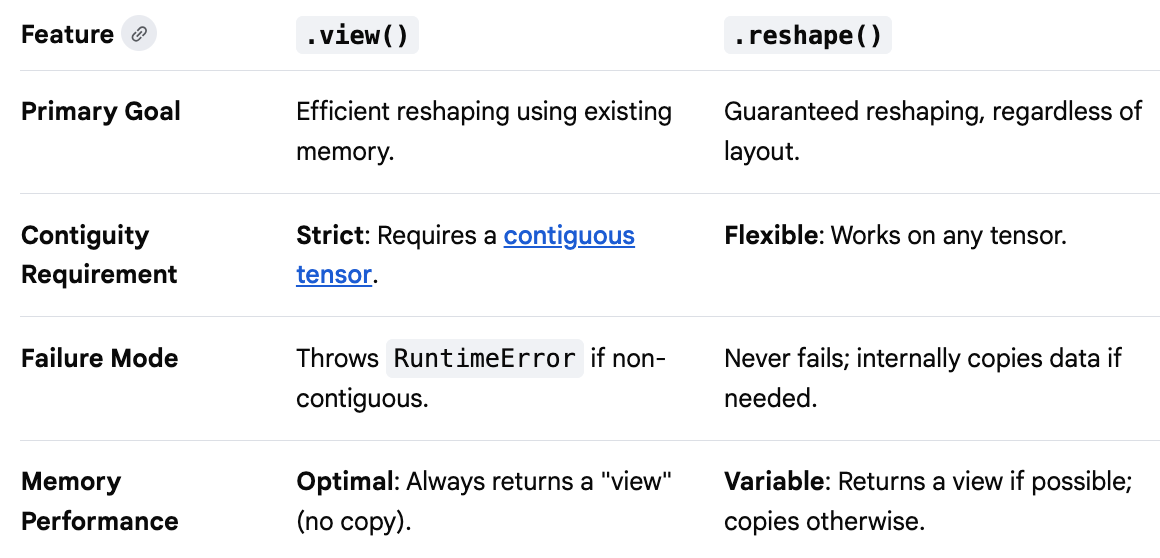

**Using -1**

In [88]:
x.reshape(5, -1)

tensor([[99,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9]])

In [89]:
x.reshape(5, -1)

tensor([[99,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9]])

### **Tensor Arithmetic**

Adding tensors can be performed a few different ways depending on the desired result.<br>

As a simple expression (**ElementWise)**:

In [44]:
a = torch.tensor([1,2,3], dtype=torch.float)
b = torch.tensor([4,5,6], dtype=torch.float)
print(a + b)

tensor([5., 7., 9.])


**Functional Form**

As arguments passed into a torch operation:

In [45]:
torch.add(a,b)

tensor([5., 7., 9.])

With an output tensor passed in as an argument:

In [46]:
result = torch.empty(3)
torch.add(a, b, out=result)  # equivalent to result=torch.add(a,b)
print(result)

tensor([5., 7., 9.])


**In-place Operations**

Changing a tensor in-place

In [47]:
a.add_(b)

tensor([5., 7., 9.])

<div class="alert alert-info"><strong>NOTE:</strong> Any operation that changes a tensor in-place is post-fixed with an underscore _.
    <br>In the above example: <tt>a.add_(b)</tt> changed <tt>a</tt>.</div>

**Pitfalls**

- In-place ops can break gradient tracking (later topic)
- Avoid unless necessary


<br>

### **Basic Tensor Operations**
<table style="display: inline-block">
<caption style="text-align: center"><strong>Arithmetic</strong></caption>
<tr><th>OPERATION</th><th>FUNCTION</th><th>DESCRIPTION</th></tr>
<tr><td>a + b</td><td>a.add(b)</td><td>element wise addition</td></tr>
<tr><td>a - b</td><td>a.sub(b)</td><td>subtraction</td></tr>
<tr><td>a * b</td><td>a.mul(b)</td><td>multiplication</td></tr>
<tr><td>a / b</td><td>a.div(b)</td><td>division</td></tr>
<tr><td>a % b</td><td>a.fmod(b)</td><td>modulo (remainder after division)</td></tr>
<tr><td>a<sup>b</sup></td><td>a.pow(b)</td><td>power</td></tr>
<tr><td>&nbsp;</td><td></td><td></td></tr>
</table>

<br>

<table style="display: inline-block">
<caption style="text-align: center"><strong>Monomial Operations</strong></caption>
<tr><th>OPERATION</th><th>FUNCTION</th><th>DESCRIPTION</th></tr>
<tr><td>|a|</td><td>torch.abs(a)</td><td>absolute value</td></tr>
<tr><td>1/a</td><td>torch.reciprocal(a)</td><td>reciprocal</td></tr>
<tr><td>$\sqrt{a}$</td><td>torch.sqrt(a)</td><td>square root</td></tr>
<tr><td>log(a)</td><td>torch.log(a)</td><td>natural log</td></tr>
<tr><td>e<sup>a</sup></td><td>torch.exp(a)</td><td>exponential</td></tr>
<tr><td>12.34  ==>  12.</td><td>torch.trunc(a)</td><td>truncated integer</td></tr>
<tr><td>12.34  ==>  0.34</td><td>torch.frac(a)</td><td>fractional component</td></tr>
</table>

<br>

<table style="display: inline-block">
<caption style="text-align: center"><strong>Trigonometry</strong></caption>
<tr><th>OPERATION</th><th>FUNCTION</th><th>DESCRIPTION</th></tr>
<tr><td>sin(a)</td><td>torch.sin(a)</td><td>sine</td></tr>
<tr><td>cos(a)</td><td>torch.sin(a)</td><td>cosine</td></tr>
<tr><td>tan(a)</td><td>torch.sin(a)</td><td>tangent</td></tr>
<tr><td>arcsin(a)</td><td>torch.asin(a)</td><td>arc sine</td></tr>
<tr><td>arccos(a)</td><td>torch.acos(a)</td><td>arc cosine</td></tr>
<tr><td>arctan(a)</td><td>torch.atan(a)</td><td>arc tangent</td></tr>
<tr><td>sinh(a)</td><td>torch.sinh(a)</td><td>hyperbolic sine</td></tr>
<tr><td>cosh(a)</td><td>torch.cosh(a)</td><td>hyperbolic cosine</td></tr>
<tr><td>tanh(a)</td><td>torch.tanh(a)</td><td>hyperbolic tangent</td></tr>
</table>

<br>

<table style="display: inline-block">
<caption style="text-align: center"><strong>Summary Statistics</strong></caption>
<tr><th>OPERATION</th><th>FUNCTION</th><th>DESCRIPTION</th></tr>
<tr><td>$\sum a$</td><td>torch.sum(a)</td><td>sum</td></tr>
<tr><td>$\bar a$</td><td>torch.mean(a)</td><td>mean</td></tr>
<tr><td>a<sub>max</sub></td><td>torch.max(a)</td><td>maximum</td></tr>
<tr><td>a<sub>min</sub></td><td>torch.min(a)</td><td>minimum</td></tr>
<tr><td colspan="3">torch.max(a,b) returns a tensor of size a<br>containing the element wise max between a and b</td></tr>
</table>

<div class="alert alert-info"><strong>NOTE:</strong> Most arithmetic operations require float values. Those that do work with integers return integer tensors.<br>
For example, <tt>torch.div(a,b)</tt> performs floor division (truncates the decimal) for integer types, and classic division for floats.</div>

### **Dot Product**

A <a href='https://en.wikipedia.org/wiki/Dot_product'>dot product</a> is the sum of the products of the corresponding entries of two 1D tensors. If the tensors are both vectors, the dot product is given as:<br>

$\begin{bmatrix} a & b & c \end{bmatrix} \;\cdot\; \begin{bmatrix} d & e & f \end{bmatrix} = ad + be + cf$

If the tensors include a column vector, then the dot product is the sum of the result of the multiplied matrices. For example:<br>
$\begin{bmatrix} a & b & c \end{bmatrix} \;\cdot\; \begin{bmatrix} d \\ e \\ f \end{bmatrix} = ad + be + cf$<br><br>
Dot products can be expressed as <a href='https://pytorch.org/docs/stable/torch.html#torch.dot'><strong><tt>torch.dot(a,b)</tt></strong></a> or `a.dot(b)` or `b.dot(a)`

In [48]:
a = torch.tensor([1,2,3], dtype=torch.float)
b = torch.tensor([4,5,6], dtype=torch.float)
print(a.mul(b)) # for reference
print()
print(a.dot(b))

tensor([ 4., 10., 18.])

tensor(32.)


<div class="alert alert-info"><strong>NOTE:</strong> There's a slight difference between <tt>torch.dot()</tt> and <tt>numpy.dot()</tt>. While <tt>torch.dot()</tt> only accepts 1D arguments and returns a dot product, <tt>numpy.dot()</tt> also accepts 2D arguments and performs matrix multiplication. We show matrix multiplication below.</div>

## **Matrix multiplication**
2D <a href='https://en.wikipedia.org/wiki/Matrix_multiplication'>Matrix multiplication</a> is possible when the number of columns in tensor <strong><tt>A</tt></strong> matches the number of rows in tensor <strong><tt>B</tt></strong>. In this case, the product of tensor <strong><tt>A</tt></strong> with size $(x,y)$ and tensor <strong><tt>B</tt></strong> with size $(y,z)$ results in a tensor of size $(x,z)$
<div>
<div align="left"><img src='../Images/Matrix_multiplication_diagram.png' align="left"><br><br>

$\begin{bmatrix} a & b & c \\
d & e & f \end{bmatrix} \;\times\; \begin{bmatrix} m & n \\ p & q \\ r & s \end{bmatrix} = \begin{bmatrix} (am+bp+cr) & (an+bq+cs) \\
(dm+ep+fr) & (dn+eq+fs) \end{bmatrix}$</div></div>

<div style="clear:both">Image source: <a href='https://commons.wikimedia.org/wiki/File:Matrix_multiplication_diagram_2.svg'>https://commons.wikimedia.org/wiki/File:Matrix_multiplication_diagram_2.svg</a></div>

Matrix multiplication can be computed using <a href='https://pytorch.org/docs/stable/torch.html#torch.mm'><strong><tt>torch.mm(a,b)</tt></strong></a> or `a.mm(b)` or `a @ b`

In [49]:
a = torch.tensor([[0,2,4],[1,3,5]], dtype=torch.float)
b = torch.tensor([[6,7],[8,9],[10,11]], dtype=torch.float)

print('a: ',a.size())
print('b: ',b.size())
print('a x b: ',torch.mm(a,b).size())

a:  torch.Size([2, 3])
b:  torch.Size([3, 2])
a x b:  torch.Size([2, 2])


In [51]:
print(torch.mm(a,b))

tensor([[56., 62.],
        [80., 89.]])


In [52]:
print(a.mm(b))

tensor([[56., 62.],
        [80., 89.]])


In [53]:
print(a @ b)

tensor([[56., 62.],
        [80., 89.]])


### **Matrix multiplication with broadcasting**
Matrix multiplication that involves <a href='https://pytorch.org/docs/stable/notes/broadcasting.html#broadcasting-semantics'>broadcasting</a> can be computed using <a href='https://pytorch.org/docs/stable/torch.html#torch.matmul'><strong><tt>torch.matmul(a,b)</tt></strong></a> or `a.matmul(b)` or `a @ b`

In [54]:
t1 = torch.randn(2, 3, 4)
t2 = torch.randn(4, 5)

print(torch.matmul(t1, t2).size())

torch.Size([2, 3, 5])


However, the same operation raises a <tt><strong>RuntimeError</strong></tt> with <tt>torch.mm()</tt>:

In [55]:
print(torch.mm(t1, t2).size())

RuntimeError: self must be a matrix

## **Advanced operations**

### **L2 or Euclidian Norm**
See <a href='https://pytorch.org/docs/stable/torch.html#torch.norm'><strong><tt>torch.norm()</tt></strong></a>

The <a href='https://en.wikipedia.org/wiki/Norm_(mathematics)#Euclidean_norm'>Euclidian Norm</a> gives the vector norm of $x$ where $x=(x_1,x_2,...,x_n)$.<br>
It is calculated as<br>

${\displaystyle \left\|{\boldsymbol {x}}\right\|_{2}:={\sqrt {x_{1}^{2}+\cdots +x_{n}^{2}}}}$


When applied to a matrix, <tt>torch.norm()</tt> returns the <a href='https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm'>Frobenius norm</a> by default.

In [56]:
x = torch.tensor([2.,5.,8.,14.])
x.norm()

tensor(17.)

### **Number of elements**
See <a href='https://pytorch.org/docs/stable/torch.html#torch.numel'><strong><tt>torch.numel()</tt></strong></a>

Returns the number of elements in a tensor.

In [57]:
x = torch.ones(3,7)
x.numel()

21

This can be useful in certain calculations like Mean Squared Error:<br>
<tt>
def mse(t1, t2):<br>
&nbsp;&nbsp;&nbsp;&nbsp;diff = t1 - t2<br>
    &nbsp;&nbsp;&nbsp;&nbsp;return torch.sum(diff * diff) / diff<strong>.numel()</strong></tt>

<br> <br>

## **When to Use PyTorch vs NumPy**

**Use NumPy when:**
- Performing simple numerical computations
- No need for gradients
- CPU computation is sufficient

**Use PyTorch when:**
- Training machine learning models
- Working with neural networks
- Need GPU acceleration
- Need automatic differentiation

## **Common Confusions**

**❗ Confusion 1: “Is PyTorch replacing NumPy?”**

No.

- NumPy is still widely used
- PyTorch builds on similar concepts

**❗ Confusion 2: “Are tensors different from arrays?”**

Conceptually similar, but tensors:

- Support GPU
- Support gradients
- Are part of a deep learning framework

**❗ Confusion 3: Device mismatch**

In [ ]:
import torch
x = torch.tensor([1,2,3])
y = torch.tensor([4,5,6]).to("cuda")

x + y   # ❌ ERROR

👉 All tensors must be on the same device.